Connected to Potato (Python 3.11.14)

In [ ]:
import os
import io
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time
import pickle
import itertools
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    auc, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

BASE_DIR = Path(__file__).resolve().parent.parent
FOLDS_DIR = os.path.join(BASE_DIR, "folds")

EXTERNAL_FOLD_DIR = os.path.join(FOLDS_DIR, "external_folds")
INTERNAL_FOLDS_DIR = os.path.join(FOLDS_DIR, "internal_folds")
GRID_SEARCH_DIR = os.path.join(FOLDS_DIR, "grid_search_xgb") 

os.makedirs(GRID_SEARCH_DIR, exist_ok=True)

TARGET = "label"

In [ ]:
def fold_loader(path_csv):
    df = pd.read_csv(path_csv)

    cols_to_drop = ['subject_id', 'window_id', 'label', 'scenario', 'protocol']
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    
    X = df.drop(columns=cols_to_drop)
    y = df[TARGET]
    return X, y

In [ ]:
param_grid_xgb = {
    'n_estimators': [180, 220, 260, 300, 340],
    'learning_rate': [0.08, 0.09, 0.1, 0.11, 0.12],    
    'max_depth': [8, 9, 10],             
    'subsample': [0.9, 1.0]
}

In [ ]:
def grid_search_xgb(INTERNAL_FOLDS_DIR, param_grid, metric_sort="f1"):
        
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(itertools.product(*param_values))
    df_combinations = pd.DataFrame(all_combinations, columns=param_names)
    
    folds = sorted([
        int(f.replace("STRESS_train_", "").replace(".csv", ""))
        for f in os.listdir(INTERNAL_FOLDS_DIR) 
        if f.startswith("STRESS_train_") and f.endswith(".csv")
    ])
    
    rows_summary = []
    rows_folds = []

    for comb_id, combo in tqdm(df_combinations.iterrows(), total=len(df_combinations), desc="Combinações XGB"):
        params = combo.to_dict()
        
        if 'n_estimators' in params: params['n_estimators'] = int(params['n_estimators'])
        if 'max_depth' in params: params['max_depth'] = int(params['max_depth'])
        
        metrics_folds = []

        for fold in folds:
            train_path = os.path.join(INTERNAL_FOLDS_DIR, f"STRESS_train_{fold}.csv")
            val_path = os.path.join(INTERNAL_FOLDS_DIR, f"STRESS_val_{fold}.csv")
            
            X_train, y_train = fold_loader(train_path)
            X_val, y_val = fold_loader(val_path)

            model = XGBClassifier(
                n_jobs=-1, 
                random_state=42, 
                use_label_encoder=False, 
                eval_metric='logloss',
                **params
            )
            
            # TREINO
            start = time.time()
            model.fit(X_train, y_train)
            runtime_train = time.time() - start
            
            # INFERÊNCIA
            start = time.time()
            y_pred = model.predict(X_val)
            y_proba = model.predict_proba(X_val)[:, 1]
            runtime_inf = time.time() - start
            
            # TAMANHO DO MODELO
            buffer = io.BytesIO()
            pickle.dump(model, buffer)
            model_size = buffer.tell()

            # MÉTRICAS
            try:
                prec, rec, _ = precision_recall_curve(y_val, y_proba)
                auprc_val = auc(rec, prec)
                roc_val = roc_auc_score(y_val, y_proba)
            except Exception as e:
                print(f"[WARN] fold {fold}, combo {comb_id}: {e}")
                auprc_val = 0
                roc_val = 0

            metrics = {
                "combination_id": comb_id,
                "fold": fold,
                "roc_auc": roc_val,
                "auprc": auprc_val,
                "f1": f1_score(y_val, y_pred),
                "precision": precision_score(y_val, y_pred),
                "recall": recall_score(y_val, y_pred),
                "runtime_train": runtime_train,
                "runtime_inf": runtime_inf,
                "model_size": model_size
            }
            metrics_folds.append(metrics)

        avg_metrics = pd.DataFrame(metrics_folds).mean(numeric_only=True).to_dict()
        for k in ['fold', 'combination_id']: 
            if k in avg_metrics: del avg_metrics[k]

        summary_row = {**{"combo_id": comb_id}, **params, **avg_metrics}
        rows_summary.append(summary_row)
        rows_folds.extend(metrics_folds)


    df_summary = pd.DataFrame(rows_summary)
    df_folds = pd.DataFrame(rows_folds)
    
    df_summary.to_csv(os.path.join(GRID_SEARCH_DIR, "xgb_grid_summary.csv"), index=False)
    df_folds.to_csv(os.path.join(GRID_SEARCH_DIR, "xgb_folds_detail.csv"), index=False)
    

    df_summary = df_summary.sort_values(by=metric_sort, ascending=False)
    
    print(f"\n--- Resultado do Grid Search XGBoost (Top 5 por {metric_sort}) ---")
    display(df_summary.head(5))
    
    best_combo = df_summary.iloc[0]
    print(f"\nMelhor Combinação XGBoost (Combo ID {best_combo['combo_id']}):")
    print(best_combo[param_names])
    
    return best_combo[param_names].to_dict()

# Executa o Grid Search
best_params_xgb = grid_search_xgb(INTERNAL_FOLDS_DIR, param_grid_xgb, metric_sort="f1")

Combinações XGB:   0%|          | 0/150 [00:00<?, ?it/s]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:07:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:07:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:07:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:07:06] WARNING: C:\actions-runner\_w


--- Resultado do Grid Search XGBoost (Top 5 por f1) ---


,combo_id,n_estimators,learning_rate,max_depth,subsample,roc_auc,auprc,f1,precision,recall,runtime_train,runtime_inf,model_size
40,40,220,0.09,10,0.9,0.906248,0.890668,0.819214,0.833186,0.805907,1.367630,0.018521,778894.7
70,70,260,0.09,10,0.9,0.905764,0.889442,0.819064,0.831171,0.807438,1.505557,0.016327,849108.1
95,95,300,0.08,10,1.0,0.903172,0.884348,0.818437,0.836588,0.801331,1.835872,0.018598,985442.3
35,35,220,0.08,10,1.0,0.903465,0.884446,0.817786,0.836560,0.800308,1.377422,0.016556,839086.9
71,71,260,0.09,10,1.0,0.904839,0.887640,0.817533,0.834664,0.801336,1.686552,0.018663,865528.7



Melhor Combinação XGBoost (Combo ID 40.0):
n_estimators     220.00
learning_rate      0.09
max_depth         10.00
subsample          0.90
Name: 40, dtype: float64


In [ ]:
def evaluate_xgb(EXTERNAL_FOLD_DIR, best_params):
    
    folds = sorted([
        int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
        for f in os.listdir(EXTERNAL_FOLD_DIR) 
        if f.startswith("STRESS_fold") and f.endswith("_train.csv")
    ])
    
    print(f"Folds Externos Identificados: {folds}")
    
    rows_eval = []
    
    if 'n_estimators' in best_params: best_params['n_estimators'] = int(best_params['n_estimators'])
    if 'max_depth' in best_params: best_params['max_depth'] = int(best_params['max_depth'])

    for fold in tqdm(folds, desc="Avaliando Externos"):
        train_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_train.csv")
        test_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_test.csv")
        
        X_train, y_train = fold_loader(train_path)
        X_test, y_test = fold_loader(test_path)
        
        model = XGBClassifier(
            n_jobs=-1, 
            random_state=42, 
            use_label_encoder=False, 
            eval_metric='logloss',
            **best_params
        )
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        
        rows_eval.append({
            "fold": fold,
            "roc_auc": roc_auc_score(y_test, y_proba),
            "auprc": auc(rec, prec),
            "f1": f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred)
        })
    
    df_results = pd.DataFrame(rows_eval)
    output_path = os.path.join(GRID_SEARCH_DIR, "xgb_final_evaluation.csv")
    df_results.to_csv(output_path, index=False)

    df_summary = df_results.agg(['mean', 'std'])
    df_summary.to_csv(os.path.join(GRID_SEARCH_DIR, "xgb_final_evaluation_summary.csv"))
    display(df_summary)

evaluate_xgb(EXTERNAL_FOLD_DIR, best_params_xgb)

Folds Externos Identificados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


Avaliando Externos:   0%|          | 0/10 [00:00<?, ?it/s]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Avaliando Externos:  10%|█         | 1/10 [00:01<00:15,  1.75s/it]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Avaliando Externos:  20%|██        | 2/10 [00:03<00:13,  1.70s/it]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:47:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,fold,roc_auc,auprc,f1,precision,recall
mean,5.50000,0.918785,0.904281,0.832208,0.834415,0.831193
std,3.02765,0.018596,0.027969,0.035062,0.038808,0.044358


Gerando Learning Curves: 100%|██████████| 10/10 [00:17<00:00,  1.71s/it]


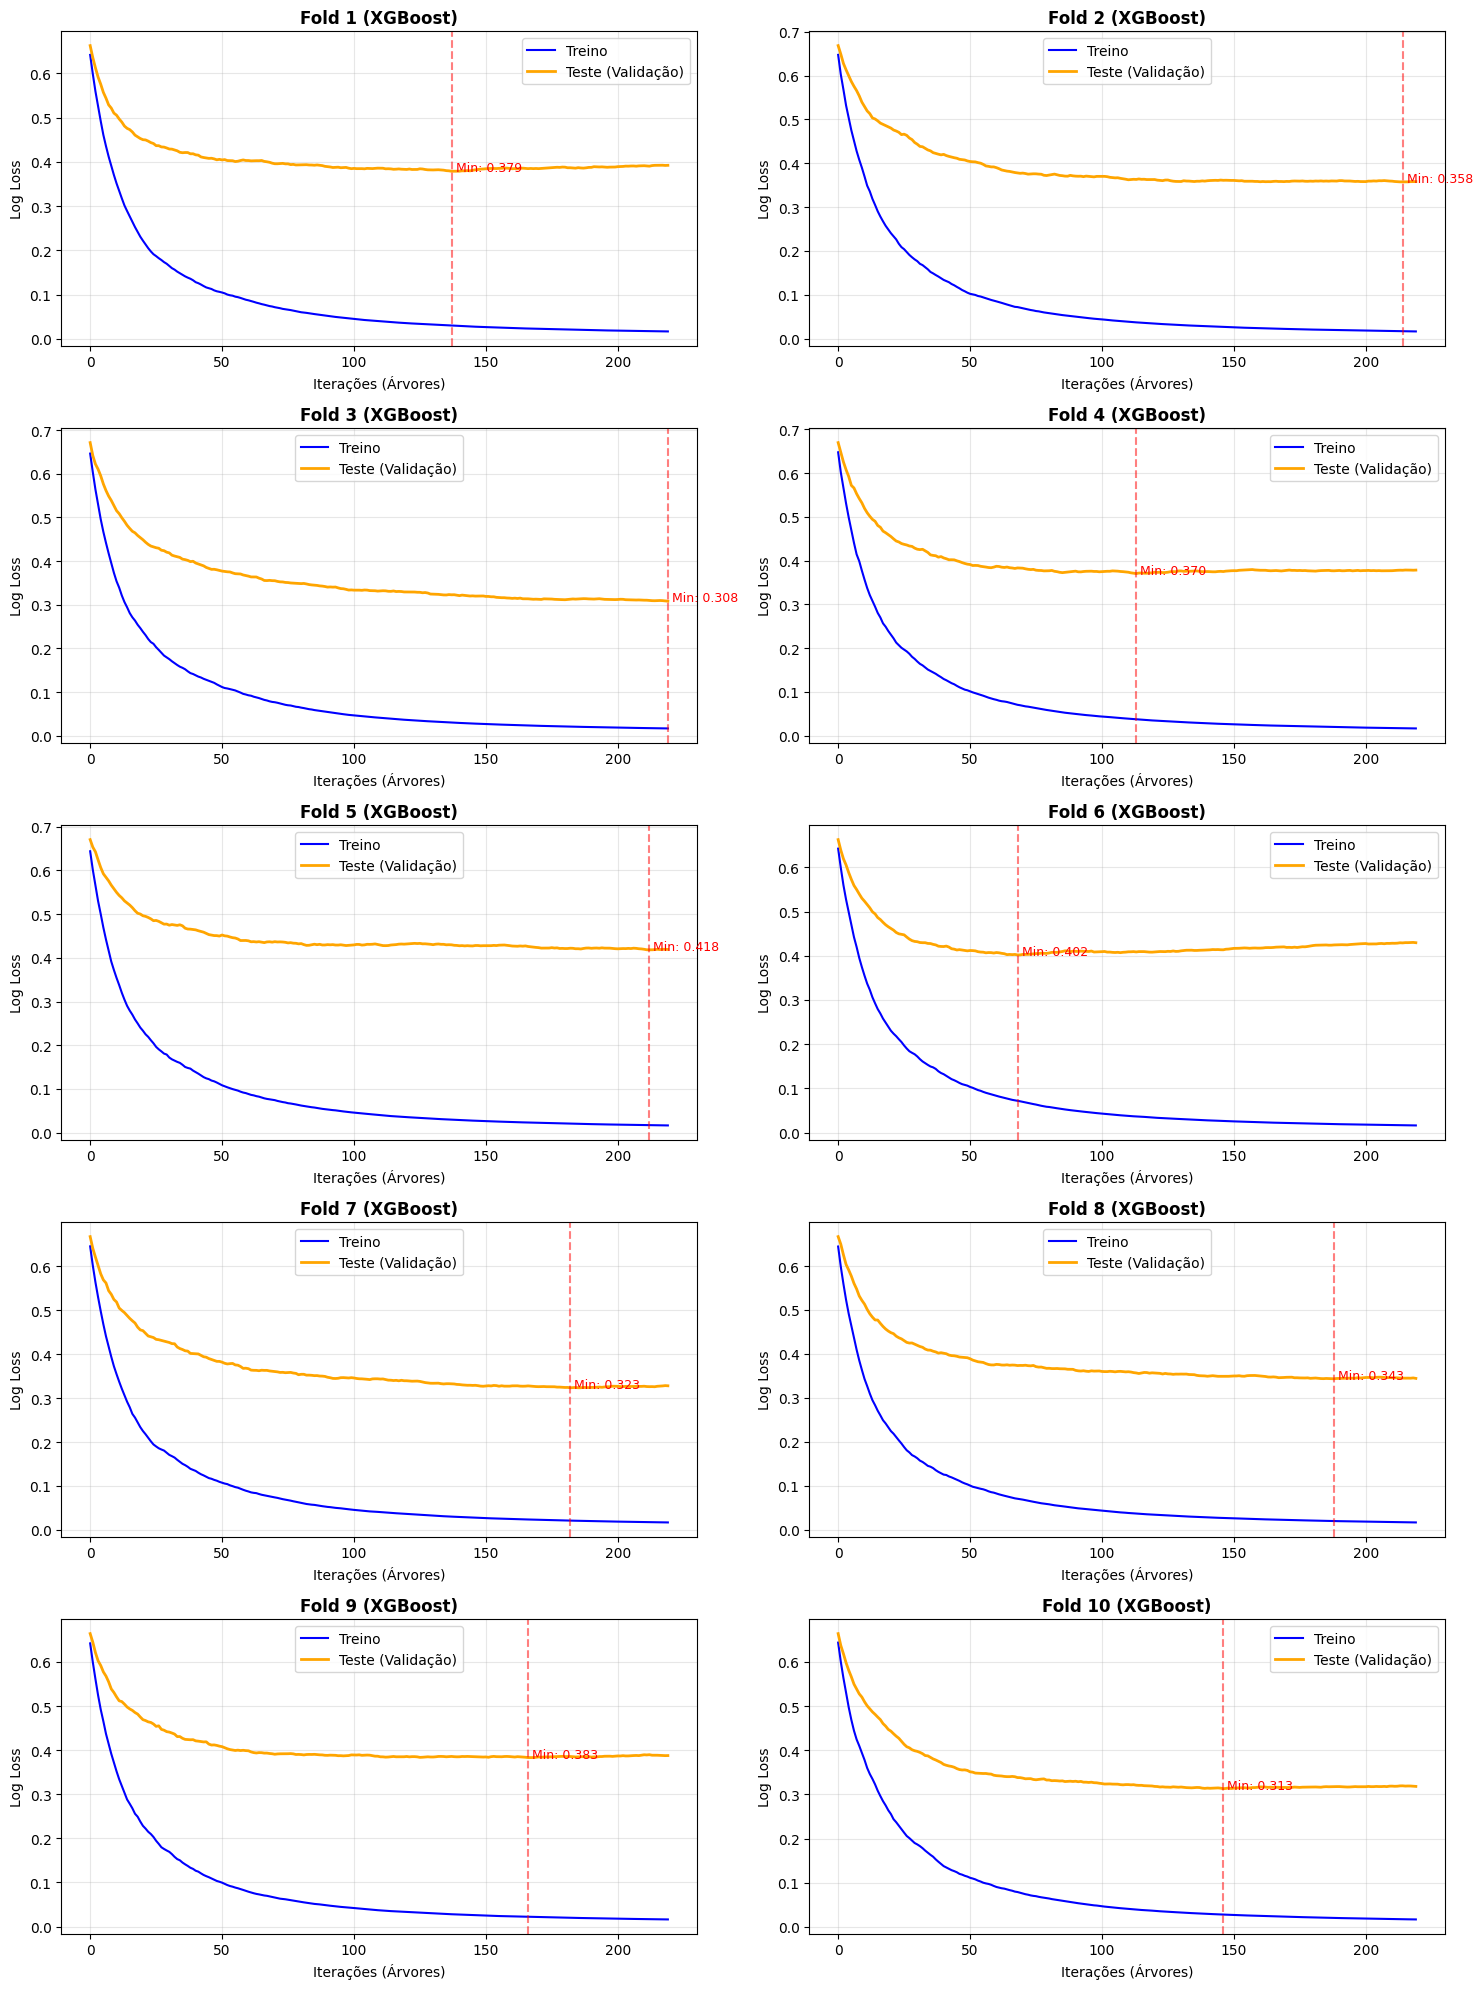

In [ ]:
def plot_learning_curves(external_dir, params):
    
    folds = sorted([
        int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
        for f in os.listdir(external_dir) 
        if f.startswith("STRESS_fold") and f.endswith("_train.csv")
    ])
    
    n_folds = len(folds)
    n_cols = 2
    n_rows = math.ceil(n_folds / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, fold in enumerate(tqdm(folds, desc="Gerando Learning Curves")):
        ax = axes[i]
        
        train_path = os.path.join(external_dir, f"STRESS_fold{fold}_train.csv")
        test_path = os.path.join(external_dir, f"STRESS_fold{fold}_test.csv")
        
        X_train, y_train = fold_loader(train_path)
        X_test, y_test = fold_loader(test_path)
        
        current_params = params.copy()
        current_params.pop('n_jobs', None) 
        
        model = XGBClassifier(**current_params)
        
        model.fit(
            X_train, y_train, 
            eval_set=[(X_train, y_train), (X_test, y_test)], 
            verbose=False
        )
        
        results = model.evals_result()
        epochs = len(results['validation_0']['logloss'])
        x_axis = range(0, epochs)
        
        ax.plot(x_axis, results['validation_0']['logloss'], label='Treino', color='blue', linewidth=1.5)
        ax.plot(x_axis, results['validation_1']['logloss'], label='Teste (Validação)', color='orange', linewidth=2)
        
        ax.set_title(f"Fold {fold} (XGBoost)", fontsize=12, fontweight='bold')
        ax.set_ylabel('Log Loss')
        ax.set_xlabel('Iterações (Árvores)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        min_loss_idx = results['validation_1']['logloss'].index(min(results['validation_1']['logloss']))
        min_loss_val = min(results['validation_1']['logloss'])
        ax.axvline(min_loss_idx, color='red', linestyle='--', alpha=0.5)
        ax.text(min_loss_idx, min_loss_val, f' Min: {min_loss_val:.3f}', color='red', fontsize=9)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_learning_curves(EXTERNAL_FOLD_DIR, best_params_xgb)

c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "

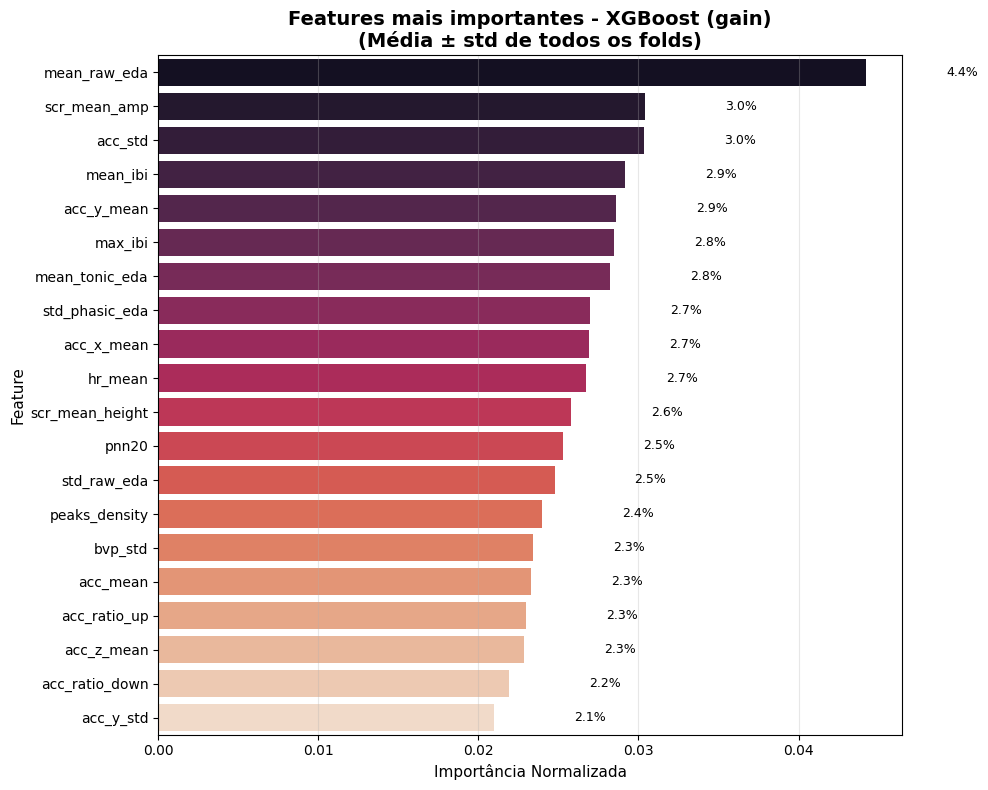

In [ ]:
def plot_xgb_feature_importance(fold_dir, best_params, importance_type='gain', top_n=20, figsize=(10, 8)):
    params = best_params.copy()
    if 'n_estimators' in params: params['n_estimators'] = int(params['n_estimators'])
    if 'max_depth' in params: params['max_depth'] = int(params['max_depth'])
    params.pop('n_jobs', None)
    params.pop('random_state', None)
    params.pop('use_label_encoder', None)
    params.pop('eval_metric', None)

    fold_ids = sorted([
        int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
        for f in os.listdir(fold_dir)
        if f.startswith("STRESS_fold") and f.endswith("_train.csv")
    ])

    fold_importances = []
    all_features = set()

    for fold_id in fold_ids:
        X_train, y_train = fold_loader(os.path.join(fold_dir, f"STRESS_fold{fold_id}_train.csv"))
        model = XGBClassifier(
            n_jobs=-1, random_state=42, use_label_encoder=False, eval_metric='logloss', **params
        )
        model.fit(X_train, y_train)
        imp = model.get_booster().get_score(importance_type=importance_type)
        all_features.update(imp.keys())
        fold_importances.append(imp)

    if not all_features:
        print("Nenhuma importância encontrada. Verifique se o modelo foi treinado corretamente.")
        return pd.DataFrame()

    feat_imp = pd.DataFrame([
        {
            'feature': feat,
            'importance_mean': np.mean([fi.get(feat, 0) for fi in fold_importances]),
            'importance_std': np.std([fi.get(feat, 0) for fi in fold_importances])
        }
        for feat in all_features
    ]).sort_values('importance_mean', ascending=False)

    feat_imp['importance_normalized'] = feat_imp['importance_mean'] / feat_imp['importance_mean'].sum()

    top_features = feat_imp.head(top_n)

    plt.figure(figsize=figsize)
    sns.barplot(
        data=top_features,
        x='importance_normalized',
        y='feature',
        palette='rocket'
    )

    plt.title(f'Features mais importantes - XGBoost ({importance_type})\n(Média ± std de todos os folds)',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importância Normalizada', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.grid(axis='x', alpha=0.3)

    for i, (v, s) in enumerate(zip(top_features['importance_normalized'], top_features['importance_std'])):
        plt.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return feat_imp[['feature', 'importance_mean', 'importance_std', 'importance_normalized']]

feature_importance_xgb = plot_xgb_feature_importance(
    fold_dir=EXTERNAL_FOLD_DIR,
    best_params=best_params_xgb,
    importance_type='gain',
    top_n=20,
    figsize=(10, 8)
)

feature_importance_xgb.to_csv(
    os.path.join(GRID_SEARCH_DIR, "xgb_feature_importance.csv"),
    index=False
)

Combo ID: 40
F1 Score: 0.8192


Avaliando XGBoost (Final):   0%|          | 0/10 [00:00<?, ?it/s]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Avaliando XGBoost (Final):  10%|█         | 1/10 [00:01<00:13,  1.55s/it]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Avaliando XGBoost (Final):  20%|██        | 2/10 [00:03<00:12,  1.62s/it]c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, it

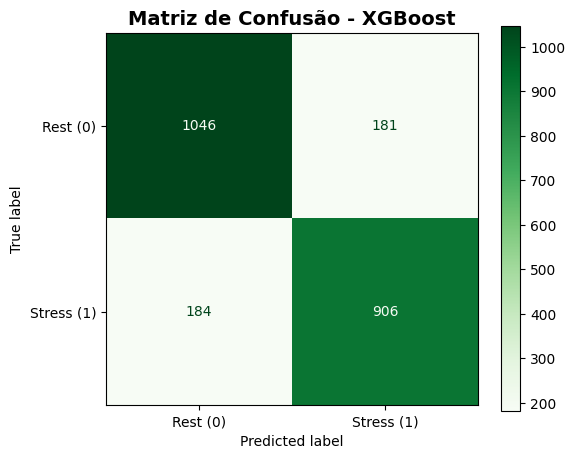

c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


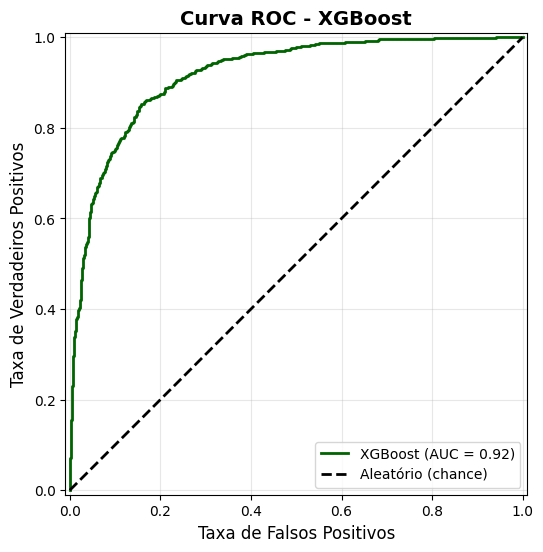

In [ ]:
df_summary_final = pd.read_csv(os.path.join(GRID_SEARCH_DIR, "xgb_grid_summary.csv"))
best_row_final = df_summary_final.loc[df_summary_final['f1'].idxmax()]

print(f"Combo ID: {int(best_row_final['combo_id'])}")
print(f"F1 Score: {best_row_final['f1']:.4f}")

xgb_params_final = {
    'n_estimators': int(best_row_final['n_estimators']),
    'learning_rate': float(best_row_final['learning_rate']),
    'max_depth': int(best_row_final['max_depth']),
    'subsample': float(best_row_final['subsample']),
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
}

folds = sorted([
    int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
    for f in os.listdir(EXTERNAL_FOLD_DIR) 
    if f.startswith("STRESS_fold") and f.endswith("_train.csv")
])

all_y_test_xgb = []
all_y_pred_xgb = []
all_y_proba_xgb = []

for fold in tqdm(folds, desc="Avaliando XGBoost (Final)"):
    train_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_train.csv")
    test_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_test.csv")
    
    X_train, y_train = fold_loader(train_path)
    X_test, y_test = fold_loader(test_path)
    
    model = XGBClassifier(**xgb_params_final)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    all_y_test_xgb.extend(y_test)
    all_y_pred_xgb.extend(y_pred)
    all_y_proba_xgb.extend(y_proba)

# MATRIZ DE CONFUSÃO
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = confusion_matrix(all_y_test_xgb, all_y_pred_xgb)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb, 
    display_labels=['Rest (0)', 'Stress (1)']
)

disp_xgb.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('Matriz de Confusão - XGBoost', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

# CURVA ROC
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    all_y_test_xgb, 
    all_y_proba_xgb, 
    ax=ax, 
    name="XGBoost",
    color="darkgreen", 
    lw=2
)

ax.plot([0, 1], [0, 1], "k--", lw=2, label="Aleatório (chance)")

ax.set_title("Curva ROC - XGBoost", fontsize=14, fontweight='bold')
ax.set_xlabel("Taxa de Falsos Positivos", fontsize=12)
ax.set_ylabel("Taxa de Verdadeiros Positivos", fontsize=12)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.show()

In [ ]:
MODEL_SAVE_PATH_XGB = os.path.join(BASE_DIR, "best_xgb_model.pkl")

# Train final model on all external fold training sets combined
all_X_final, all_y_final = [], []
for fold_id in folds:
    X_fold, y_fold = fold_loader(os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold_id}_train.csv"))
    all_X_final.append(X_fold)
    all_y_final.append(y_fold)
X_final = pd.concat(all_X_final, ignore_index=True)
y_final = pd.concat(all_y_final, ignore_index=True)

final_model_xgb = XGBClassifier(**xgb_params_final)
final_model_xgb.fit(X_final, y_final)

with open(MODEL_SAVE_PATH_XGB, 'wb') as f:
    pickle.dump(final_model_xgb, f)

c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:48:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import os
import io
import time
import pickle
import itertools
from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    auc, precision_recall_curve,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


BASE_DIR = Path(__file__).resolve().parent.parent
FOLDS_DIR = os.path.join(BASE_DIR, "folds")

EXTERNAL_FOLD_DIR = os.path.join(FOLDS_DIR, "external_folds")
INTERNAL_FOLDS_DIR = os.path.join(FOLDS_DIR, "internal_folds")
GRID_SEARCH_DIR = os.path.join(FOLDS_DIR, "grid_search_rf")

os.makedirs(GRID_SEARCH_DIR, exist_ok=True)

TARGET = "label"
base_seed = 42

LEARNING_CURVE_STEP = 5
FEATURE_IMPORTANCE_TOP_N = 20
FEATURE_LABEL_OFFSET = 0.001

In [ ]:
def fold_loader(path_csv):
    df = pd.read_csv(path_csv)

    cols_to_drop = [
                    'subject_id', 
                    'window_id', 
                    'label', 
                    'scenario', 
                    'protocol'
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    
    X = df.drop(columns=cols_to_drop)
    y = df[TARGET]
    return X, y

In [ ]:
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_features': [0.6, 0.7, 0.8],
    'min_samples_leaf': [1, 2, 3]
}

In [ ]:
def grid_search(INTERNAL_FOLDS_DIR, param_grid, metric_sort="f1"):
    
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    all_combinations = list(itertools.product(*param_values))
    df_combinations = pd.DataFrame(all_combinations, columns=param_names)
    
    folds = sorted([
        int(f.replace("STRESS_train_", "").replace(".csv", ""))
        for f in os.listdir(INTERNAL_FOLDS_DIR) 
        if f.startswith("STRESS_train_") and f.endswith(".csv")
    ])
    
    print(f"Folds Internos Identificados: {folds}")
    
    rows_summary = []
    rows_folds = []

    for comb_id, combo in tqdm(df_combinations.iterrows(), total=len(df_combinations), desc="Avaliando Combinações"):
        params = combo.to_dict()
        
        if 'n_estimators' in params: params['n_estimators'] = int(params['n_estimators'])
        if 'min_samples_leaf' in params: params['min_samples_leaf'] = int(params['min_samples_leaf'])
        
        metrics_folds = []

        # TREINO E VALIDAÇÃO
        for fold in folds:
            train_path = os.path.join(INTERNAL_FOLDS_DIR, f"STRESS_train_{fold}.csv")
            val_path = os.path.join(INTERNAL_FOLDS_DIR, f"STRESS_val_{fold}.csv")
            
            X_train, y_train = fold_loader(train_path)
            X_val, y_val = fold_loader(val_path)

            model = RandomForestClassifier(n_jobs=-1, random_state=42, **params)
            
            # TREINO
            start = time.time()
            model.fit(X_train, y_train)
            runtime_train = time.time() - start
            
            # INFERÊNCIA
            start = time.time()
            y_pred = model.predict(X_val)
            y_proba = model.predict_proba(X_val)[:, 1]
            runtime_inf = time.time() - start
            
            # TAMANHO DO MODELO
            buffer = io.BytesIO()
            pickle.dump(model, buffer)
            model_size = buffer.tell()

            # MÉTRICAS
            precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_proba)
            roc_auc = roc_auc_score(y_val, y_proba)
            auprc = auc(recall_curve, precision_curve)
            
            
            metrics = {
                "combination_id": comb_id,
                "fold": fold,
                "roc_auc": roc_auc,
                "auprc": auprc,
                "f1": f1_score(y_val, y_pred),
                "precision": precision_score(y_val, y_pred),
                "recall": recall_score(y_val, y_pred),
                "runtime_train": runtime_train,
                "runtime_inf": runtime_inf,
                "model_size": model_size
            }
            metrics_folds.append(metrics)

        avg_metrics = pd.DataFrame(metrics_folds).mean(numeric_only=True).to_dict()
        summary_row = {**{"combo_id": comb_id}, **params, **avg_metrics}
        rows_summary.append(summary_row)
        rows_folds.extend(metrics_folds)

    df_summary = pd.DataFrame(rows_summary)
    df_folds = pd.DataFrame(rows_folds)
    
    df_summary.to_csv(os.path.join(GRID_SEARCH_DIR, "grid_search_summary.csv"), index=False)
    df_folds.to_csv(os.path.join(GRID_SEARCH_DIR, "grid_search_folds_detail.csv"), index=False)
    
    df_summary = df_summary.sort_values(by=metric_sort, ascending=False)
    

    display(df_summary)
    
    best_combo = df_summary.iloc[0]
 
    print(best_combo[param_names])
    
    return best_combo[param_names].to_dict()

best_params = grid_search(INTERNAL_FOLDS_DIR, param_grid, metric_sort="f1")

Folds Internos Identificados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


Avaliando Combinações: 100%|██████████| 27/27 [06:54<00:00, 15.35s/it]


,combo_id,n_estimators,max_features,min_samples_leaf,combination_id,fold,roc_auc,auprc,f1,precision,recall,runtime_train,runtime_inf,model_size
18,18,250,0.6,1,18.0,5.5,0.900039,0.885245,0.803460,0.821563,0.786548,1.546916,0.324495,6896155.8
0,0,150,0.6,1,0.0,5.5,0.898734,0.884547,0.802117,0.822727,0.782972,0.688826,0.150848,4140857.0
25,25,250,0.8,2,25.0,5.5,0.895105,0.880534,0.801349,0.818084,0.785515,1.779511,0.335101,6051273.4
9,9,200,0.6,1,9.0,5.5,0.899782,0.885183,0.800755,0.820184,0.782469,1.184549,0.252336,5518497.5
13,13,200,0.7,2,13.0,5.5,0.894463,0.878983,0.800083,0.819437,0.781962,1.242823,0.260589,4909884.7
15,15,200,0.8,1,15.0,5.5,0.897275,0.883845,0.799940,0.820417,0.780918,1.446019,0.278594,5343053.0
21,21,250,0.7,1,21.0,5.5,0.899151,0.884690,0.799427,0.821364,0.779408,1.636117,0.317910,6786586.0
16,16,200,0.8,2,16.0,5.5,0.894308,0.879629,0.799263,0.816013,0.783482,1.346125,0.258476,4844012.7
24,24,250,0.8,1,24.0,5.5,0.898326,0.884995,0.798803,0.819532,0.779387,1.806433,0.337911,6683034.0
6,6,150,0.8,1,6.0,5.5,0.895724,0.882615,0.798649,0.820178,0.778893,0.803678,0.143190,4009881.0


n_estimators        250.0
max_features          0.6
min_samples_leaf      1.0
Name: 18, dtype: float64


In [ ]:
def evaluate_model(EXTERNAL_FOLD_DIR, best_params):
    
    folds = sorted([
        int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
        for f in os.listdir(EXTERNAL_FOLD_DIR) 
        if f.startswith("STRESS_fold") and f.endswith("_train.csv")
    ])
    
    print(f"Folds Externos Identificados: {folds}")
    
    rows_eval = []
    
    # Ajuste dos tipos
    if 'n_estimators' in best_params: best_params['n_estimators'] = int(best_params['n_estimators'])
    if 'min_samples_leaf' in best_params: best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])

    for fold in tqdm(folds, desc="Folds Externos"):

        train_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_train.csv")
        test_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_test.csv")
        
        X_train, y_train = fold_loader(train_path)
        X_test, y_test = fold_loader(test_path)
        
        model = RandomForestClassifier(n_jobs=-1, random_state=42, **best_params)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Métricas Finais
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
        
        rows_eval.append({
            "fold": fold,
            "roc_auc": roc_auc_score(y_test, y_proba),
            "auprc": auc(recall_curve, precision_curve),
            "f1": f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred)
        })
    
    df_results = pd.DataFrame(rows_eval)
    output_path = os.path.join(GRID_SEARCH_DIR, "Evaluation_results.csv")
    df_results.to_csv(output_path, index=False)

    df_summary = df_results.agg(['mean', 'std'])
    df_summary.to_csv(os.path.join(GRID_SEARCH_DIR, "Evaluation_results_summary.csv"))
    display(df_summary)

evaluate_model(EXTERNAL_FOLD_DIR, best_params)

Folds Externos Identificados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


Folds Externos: 100%|██████████| 10/10 [00:20<00:00,  2.05s/it]


,fold,roc_auc,auprc,f1,precision,recall
mean,5.50000,0.912278,0.903731,0.828254,0.828271,0.829358
std,3.02765,0.014822,0.019228,0.010007,0.026034,0.023370


In [ ]:
best_params_rf = {
    'n_estimators': 250,      
    'max_features': 0.6,
    'min_samples_leaf': 1,
    'n_jobs': -1,
    'random_state': 42
}

Processando Folds: 100%|██████████| 10/10 [08:58<00:00, 53.85s/it]


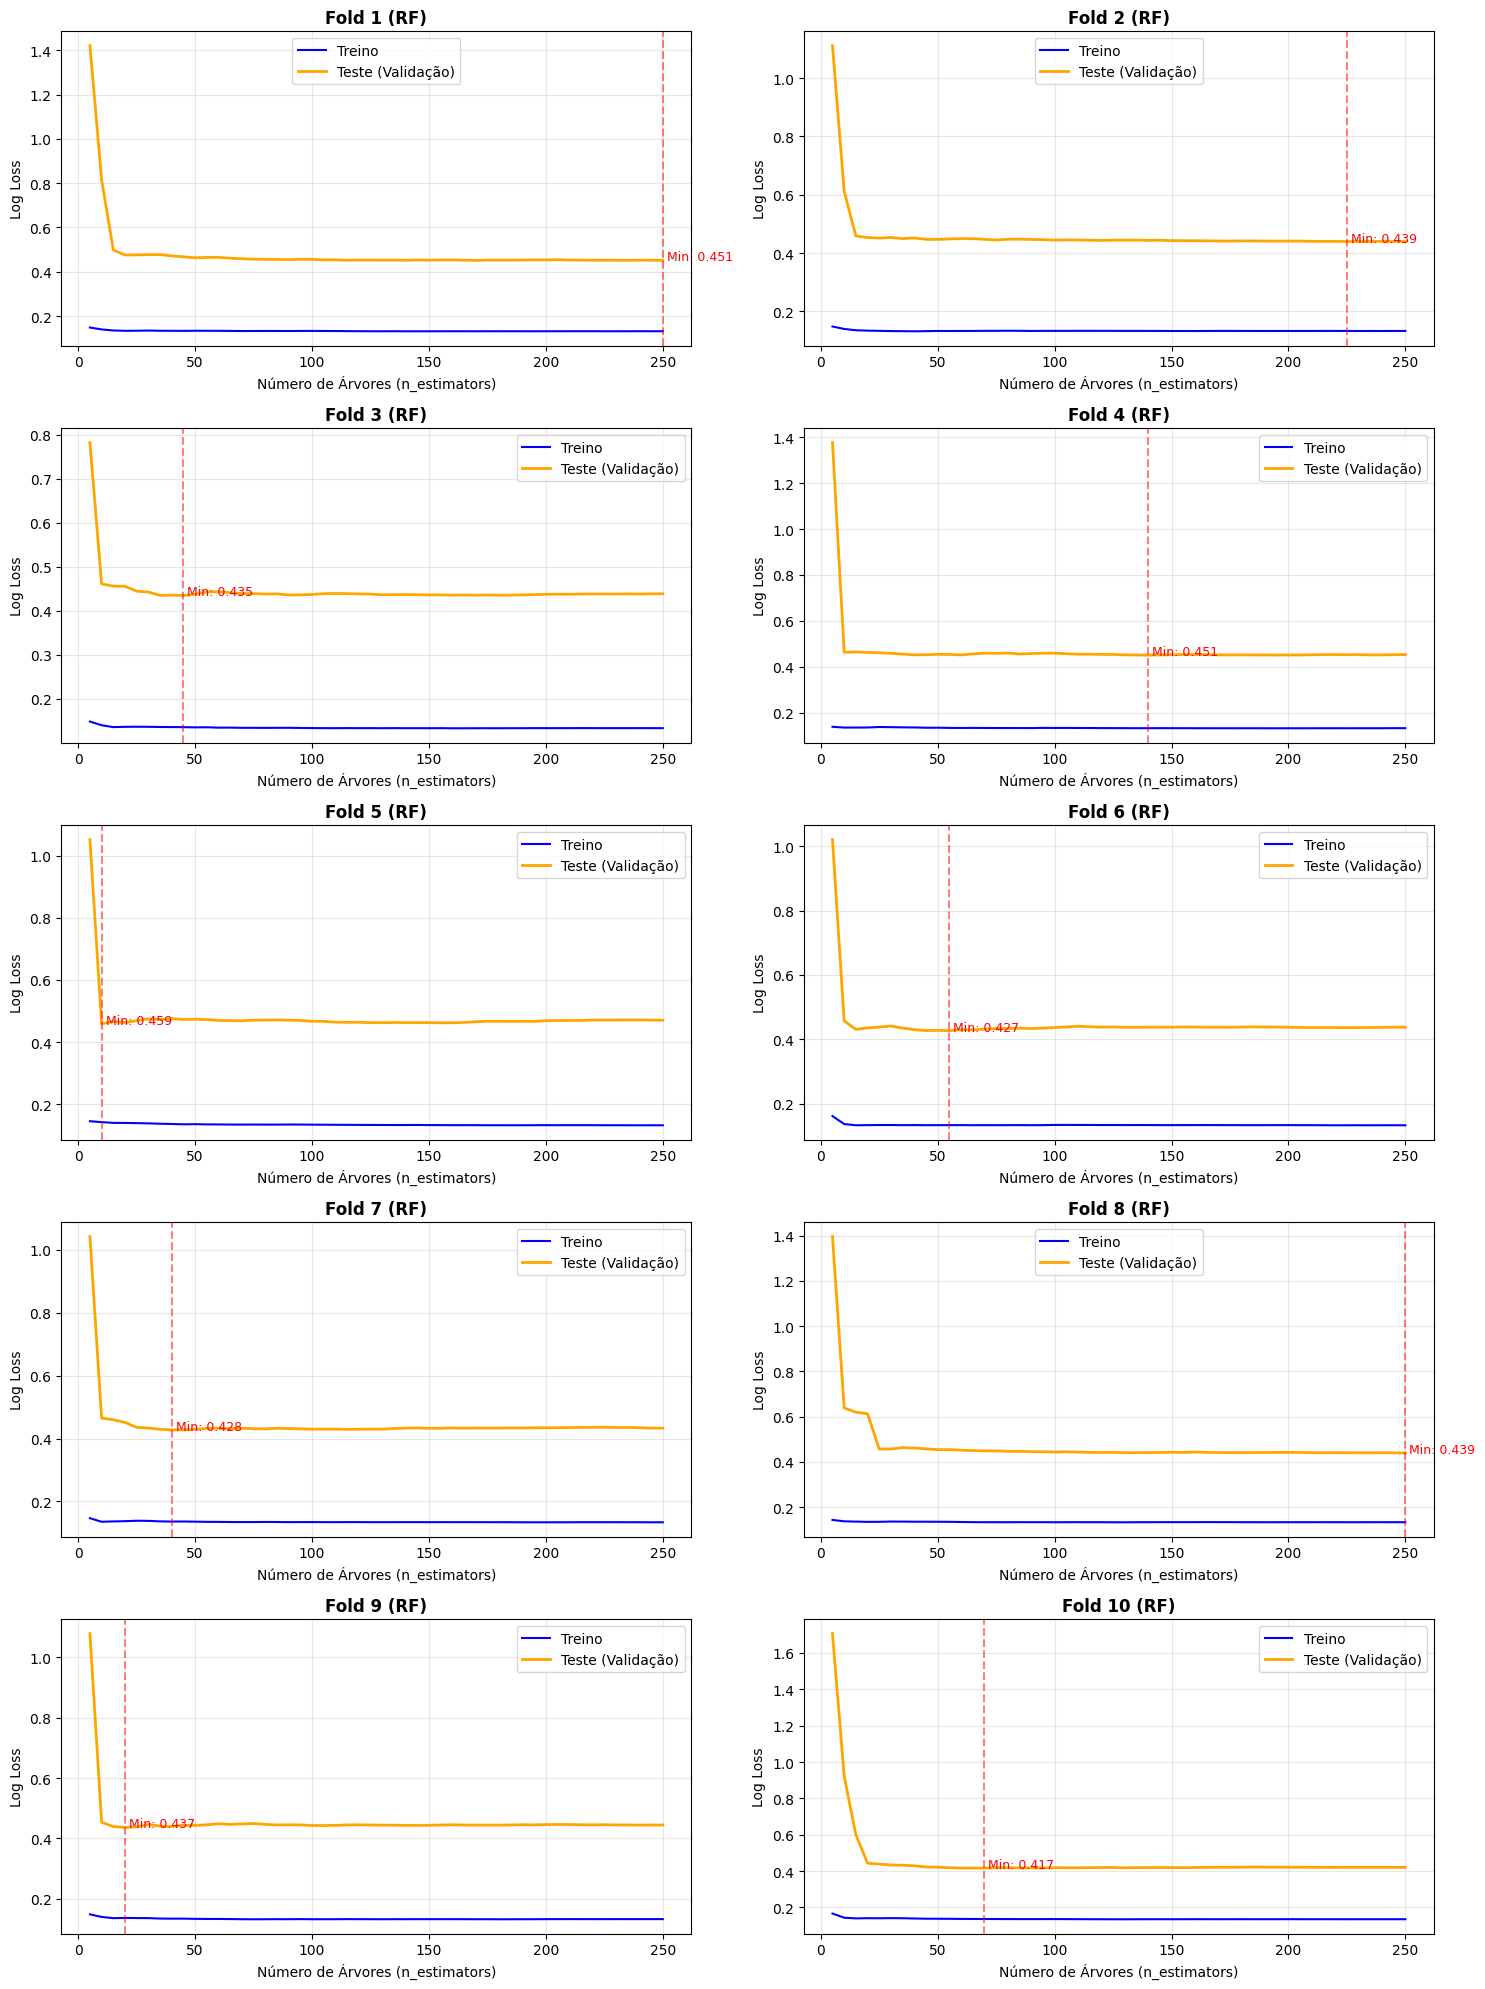

In [ ]:
def plot_learning_curves(EXTERNAL_FOLD_DIR, params):

    folds = sorted([
        int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
        for f in os.listdir(EXTERNAL_FOLD_DIR) 
        if f.startswith("STRESS_fold") and f.endswith("_train.csv")
    ])
    

    n_folds = len(folds)
    n_cols = 2
    n_rows = math.ceil(n_folds / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    step_size = LEARNING_CURVE_STEP

    max_trees = params['n_estimators']
    
    rf_params = params.copy()
    
    if 'n_estimators' in rf_params:
        del rf_params['n_estimators']
    
    if 'random_state' in rf_params:
        del rf_params['random_state']

    for i, fold in enumerate(tqdm(folds, desc="Processando Folds")):
        ax = axes[i]
        
        train_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_train.csv")
        test_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_test.csv")
        
        X_train, y_train = fold_loader(train_path)
        X_test, y_test = fold_loader(test_path)
        
        train_loss = []
        test_loss = []
        n_trees_axis = []
        
        for n_trees in range(step_size, max_trees + 1, step_size):
            
            model = RandomForestClassifier(
                n_estimators=n_trees, 
                random_state=base_seed,  
                **rf_params
            )
        
            model.fit(X_train, y_train)
            
            proba_train = model.predict_proba(X_train)
            proba_test = model.predict_proba(X_test)
            
            loss_train = log_loss(y_train, proba_train)
            loss_test = log_loss(y_test, proba_test)
            
            train_loss.append(loss_train)
            test_loss.append(loss_test)
            n_trees_axis.append(n_trees)
        
        ax.plot(n_trees_axis, train_loss, label='Treino', color='blue', linewidth=1.5)
        ax.plot(n_trees_axis, test_loss, label='Teste (Validação)', color='orange', linewidth=2)
        
        ax.set_title(f"Fold {fold} (RF)", fontsize=12, fontweight='bold')
        ax.set_ylabel('Log Loss')
        ax.set_xlabel('Número de Árvores (n_estimators)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        min_loss_val = min(test_loss)
        min_loss_idx = test_loss.index(min_loss_val)
        min_loss_trees = n_trees_axis[min_loss_idx]
        
        ax.axvline(min_loss_trees, color='red', linestyle='--', alpha=0.5)
        ax.text(min_loss_trees, min_loss_val, f' Min: {min_loss_val:.3f}', color='red', fontsize=9)


    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_learning_curves(EXTERNAL_FOLD_DIR, best_params_rf)

In [ ]:
def plot_rf_feature_importance(fold_dir, best_params, top_n=FEATURE_IMPORTANCE_TOP_N, figsize=(10, 8)):
    params = best_params.copy()
    params.pop('n_jobs', None)

    fold_ids = sorted([
        int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
        for f in os.listdir(fold_dir)
        if f.startswith("STRESS_fold") and f.endswith("_train.csv")
    ])

    all_importances = []
    feature_names = None

    for fold_id in fold_ids:
        X_train, y_train = fold_loader(os.path.join(fold_dir, f"STRESS_fold{fold_id}_train.csv"))
        model = RandomForestClassifier(n_jobs=-1, **params)
        model.fit(X_train, y_train)
        all_importances.append(model.feature_importances_)
        if feature_names is None:
            feature_names = X_train.columns

    importances_arr = np.array(all_importances)
    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': importances_arr.mean(axis=0),
        'importance_std': importances_arr.std(axis=0)
    }).sort_values('importance_mean', ascending=False)

    top_features = feat_imp.head(top_n)

    plt.figure(figsize=figsize)
    sns.barplot(
        data=top_features,
        x='importance_mean',
        y='feature',
        palette='viridis'
    )

    plt.title('Features mais importantes para Random Forest\n(Média ± std de todos os folds)', fontsize=14, fontweight='bold')
    plt.xlabel('Importância Média (Mean Decrease Impurity)', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.grid(axis='x', alpha=0.3)

    for i, (v, s) in enumerate(zip(top_features['importance_mean'], top_features['importance_std'])):
        plt.text(v + FEATURE_LABEL_OFFSET, i, f'{v:.4f}±{s:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    return feat_imp

<ipython-input-17-d9704520480f>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


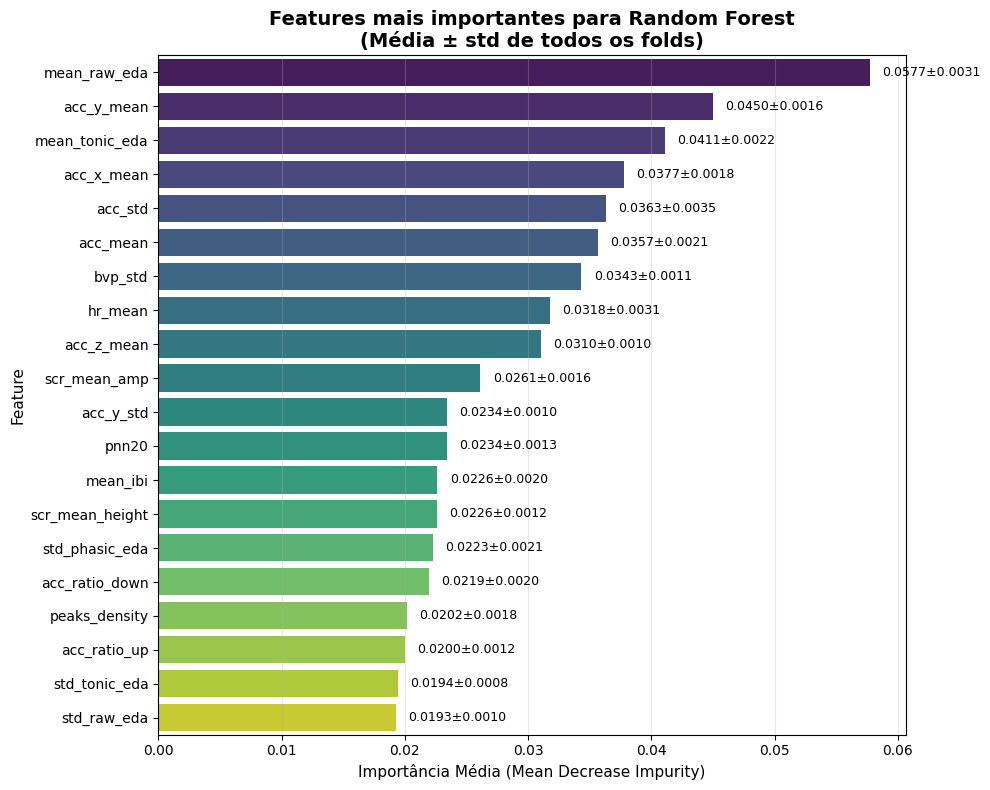

In [ ]:
feature_importance_df = plot_rf_feature_importance(
    fold_dir=EXTERNAL_FOLD_DIR,
    best_params=best_params_rf,
    top_n=FEATURE_IMPORTANCE_TOP_N,
    figsize=(10, 8)
)

feature_importance_df.to_csv(
    os.path.join(GRID_SEARCH_DIR, "rf_feature_importance.csv"),
    index=False
)

Total de Folds: 10


Avaliando Random Forest nos Folds: 100%|██████████| 10/10 [00:21<00:00,  2.16s/it]


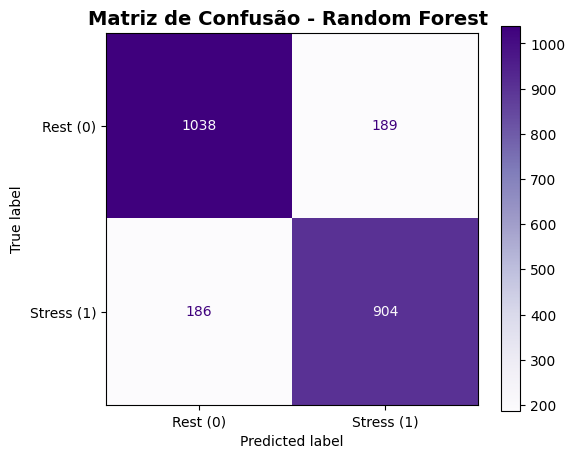

c:\Users\diego\miniconda3\envs\Potato\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


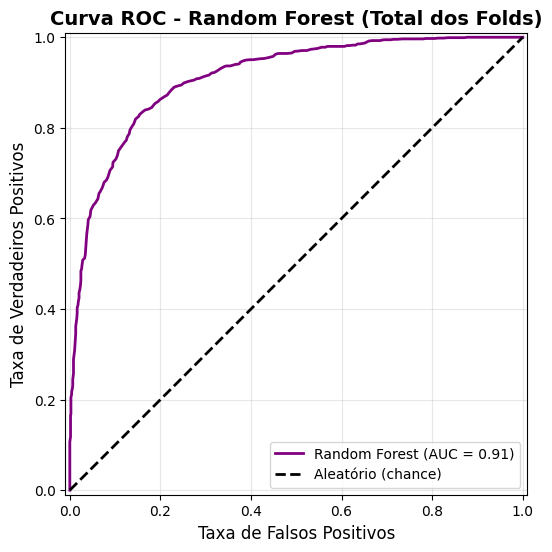

In [ ]:
rf_params = {
    'n_estimators': 250,      
    'max_features': 0.6,
    #'max_depth': 15,          
    'min_samples_leaf': 1,   
    'n_jobs': -1,             
    'random_state': 42
}

folds = sorted([
    int(f.replace("STRESS_fold", "").replace("_train.csv", ""))
    for f in os.listdir(EXTERNAL_FOLD_DIR) 
    if f.startswith("STRESS_fold") and f.endswith("_train.csv")
])

print(f"Total de Folds: {len(folds)}")

all_y_test_rf = []
all_y_pred_rf = []
all_y_proba_rf = []

for fold in tqdm(folds, desc="Avaliando Random Forest nos Folds"):
    train_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_train.csv")
    test_path = os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold}_test.csv")
    
    X_train, y_train = fold_loader(train_path)
    X_test, y_test = fold_loader(test_path)
    
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    all_y_test_rf.extend(y_test)
    all_y_pred_rf.extend(y_pred)
    all_y_proba_rf.extend(y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(all_y_test_rf, all_y_pred_rf)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf, 
    display_labels=['Rest (0)', 'Stress (1)']
)

disp_rf.plot(
    ax=ax, 
    cmap='Purples',
    values_format='d'
)

plt.title('Matriz de Confusão - Random Forest ', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    all_y_test_rf, 
    all_y_proba_rf, 
    ax=ax, 
    name="Random Forest",
    color="purple", 
    lw=2
)

ax.plot([0, 1], [0, 1], "k--", lw=2, label="Aleatório (chance)")

ax.set_title("Curva ROC - Random Forest (Total dos Folds)", fontsize=14, fontweight='bold')
ax.set_xlabel("Taxa de Falsos Positivos", fontsize=12)
ax.set_ylabel("Taxa de Verdadeiros Positivos", fontsize=12)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.show()

In [ ]:
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "best_rf_model.pkl")

# Train final model on all external fold training sets combined
all_X_final, all_y_final = [], []
for fold_id in folds:
    X_fold, y_fold = fold_loader(os.path.join(EXTERNAL_FOLD_DIR, f"STRESS_fold{fold_id}_train.csv"))
    all_X_final.append(X_fold)
    all_y_final.append(y_fold)
X_final = pd.concat(all_X_final, ignore_index=True)
y_final = pd.concat(all_y_final, ignore_index=True)

final_model = RandomForestClassifier(**best_params_rf)
final_model.fit(X_final, y_final)

with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(final_model, f)

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


BASE_DIR = Path(__file__).resolve().parent.parent
RF_RESULTS = os.path.join(BASE_DIR, "folds", "grid_search_rf", "Evaluation_results.csv")
XGB_RESULTS = os.path.join(BASE_DIR, "folds", "grid_search_xgb", "xgb_final_evaluation.csv")

In [ ]:
df_rf  = pd.read_csv(RF_RESULTS)
df_xgb = pd.read_csv(XGB_RESULTS)

In [ ]:
df_rf.columns = [c.lower().strip() for c in df_rf.columns]
df_xgb.columns = [c.lower().strip() for c in df_xgb.columns]

In [ ]:
df_rf.columns

Index(['fold', 'roc_auc', 'auprc', 'f1', 'precision', 'recall'], dtype='object')

In [ ]:
required_cols = ['fold', 'f1', 'roc_auc', 'precision', 'recall']

for df, name in [(df_rf, 'RF'), (df_xgb, 'XGB')]:
    print(f'Colunas: {df.columns.tolist()}')

df_compare = (
    df_rf[required_cols]
    .merge(
        df_xgb[required_cols],
        on='fold',
        suffixes=('_rf', '_xgb')
    )
)
display(df_compare.head(10))

Colunas: ['fold', 'roc_auc', 'auprc', 'f1', 'precision', 'recall']
Colunas: ['fold', 'roc_auc', 'auprc', 'f1', 'precision', 'recall']


,fold,f1_rf,roc_auc_rf,precision_rf,recall_rf,f1_xgb,roc_auc_xgb,precision_xgb,recall_xgb
0,1,0.831050,0.900947,0.827273,0.834862,0.796380,0.897218,0.785714,0.807339
1,2,0.824645,0.923025,0.852941,0.798165,0.803922,0.917580,0.863158,0.752294
2,3,0.831050,0.925151,0.827273,0.834862,0.862385,0.939285,0.862385,0.862385
3,4,0.810573,0.895353,0.779661,0.844037,0.815789,0.917655,0.781513,0.853211
4,5,0.814480,0.887521,0.803571,0.825688,0.774194,0.888491,0.777778,0.770642
5,6,0.828829,0.906318,0.814159,0.844037,0.814815,0.902066,0.822430,0.807339
6,7,0.826923,0.913292,0.868687,0.788991,0.855814,0.932050,0.867925,0.844037
7,8,0.844444,0.927997,0.818966,0.871560,0.871560,0.925252,0.871560,0.871560
8,9,0.833333,0.911302,0.841121,0.825688,0.868778,0.921116,0.857143,0.880734
9,10,0.837209,0.931869,0.849057,0.825688,0.858447,0.947135,0.854545,0.862385


 Teste de Hipótese para cada métrica

In [ ]:
ttest_results = []
for metric, label in stats_metricas.items():
    diff = df_compare[f'{metric}_rf'] - df_compare[f'{metric}_xgb']
    _, p_shapiro = stats.shapiro(diff)
    normal = p_shapiro >= 0.05

    if normal:
        t_stat, p_value = stats.ttest_rel(
            df_compare[f'{metric}_rf'],
            df_compare[f'{metric}_xgb']
        )
        test_used = 'paired t-test'
    else:
        t_stat, p_value = stats.wilcoxon(
            df_compare[f'{metric}_rf'],
            df_compare[f'{metric}_xgb'],
            zero_method='wilcox'
        )
        test_used = 'Wilcoxon'

    ttest_results.append({
        'Métrica': label,
        'Shapiro p-value': round(p_shapiro, 4),
        'Normalidade': 'Sim' if normal else 'Não',
        'Teste Usado': test_used,
        't_stat (RF - XGB)': t_stat,
        'p-value': p_value,
        'Significativo (p < 0.05)': 'Sim' if p_value < 0.05 else 'Não'
    })

df_ttest = pd.DataFrame(ttest_results)
df_ttest

,Métrica,Shapiro p-value,Normalidade,Teste Usado,t_stat (RF - XGB),p-value,Significativo (p < 0.05)
0,ROC AUC,0.1214,Sim,paired t-test,-1.928200,0.085920,Não
1,F1,0.1172,Sim,paired t-test,-0.430909,0.676671,Não
2,Precision,0.7669,Sim,paired t-test,-0.724231,0.487322,Não
3,Recall,0.3549,Sim,paired t-test,-0.140028,0.891722,Não


 Teste Não-Paramétrico Wilcoxon Signed-Rank

In [ ]:
metrics = [
    ('ROC AUC', 'roc_auc_rf', 'roc_auc_xgb'),
    ('F1 Score', 'f1_rf', 'f1_xgb'),
    ('Precision', 'precision_rf', 'precision_xgb'),
    ('Recall', 'recall_rf', 'recall_xgb')
]

wilcoxon_results = []
for name, col_rf, col_xgb in metrics:
    stat, p_val = stats.wilcoxon(df_compare[col_rf], df_compare[col_xgb], zero_method='wilcox')
    wilcoxon_results.append({
        'Métrica': name,
        'w_stat': stat,
        'p-value': p_val,
        'Significativo (p < 0.05)': 'Sim' if p_val < 0.05 else 'Não'
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results)
df_wilcoxon

,Métrica,w_stat,p-value,Significativo (p < 0.05)
0,ROC AUC,14.0,0.193359,Não
1,F1 Score,23.0,0.695312,Não
2,Precision,17.0,0.322266,Não
3,Recall,20.5,0.843750,Não


 Resultados

<ipython-input-24-2d7c52d398ee>:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Random Forest', 'XGBoost'],
<ipython-input-24-2d7c52d398ee>:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Random Forest', 'XGBoost'],
<ipython-input-24-2d7c52d398ee>:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Random Forest', 'XGBoost'],
<ipython-input-24-2d7c52d398ee>:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; su

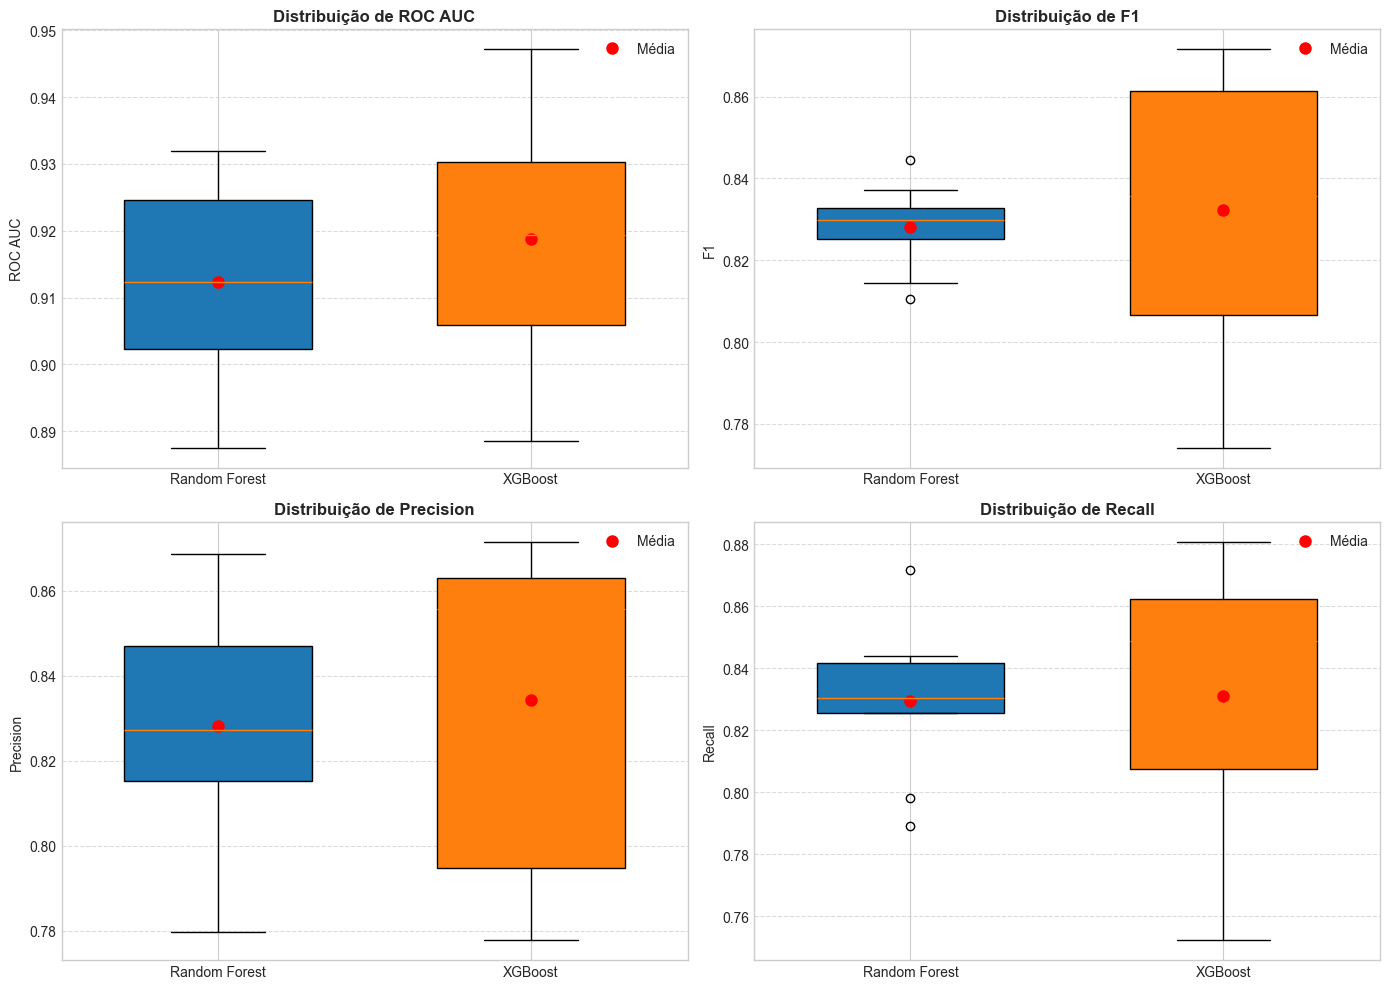

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e']

#
for idx, (metric, label) in enumerate(stats_metricas.items()):
    data_to_plot = [df_compare[f'{metric}_rf'], df_compare[f'{metric}_xgb']]
    bp = axes[idx].boxplot(data_to_plot, labels=['Random Forest', 'XGBoost'], 
                            patch_artist=True, widths=0.6)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[idx].set_title(f'Distribuição de {label}', 
                        fontsize=12, 
                        fontweight='bold'
    )
    axes[idx].set_ylabel(label, fontsize=10)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)
    means = [df_compare[f'{metric}_rf'].mean(), df_compare[f'{metric}_xgb'].mean()]
    axes[idx].plot([1, 2], means, 'o', color='red', markersize=8, label='Média')
    axes[idx].legend()

plt.tight_layout()
plt.show()

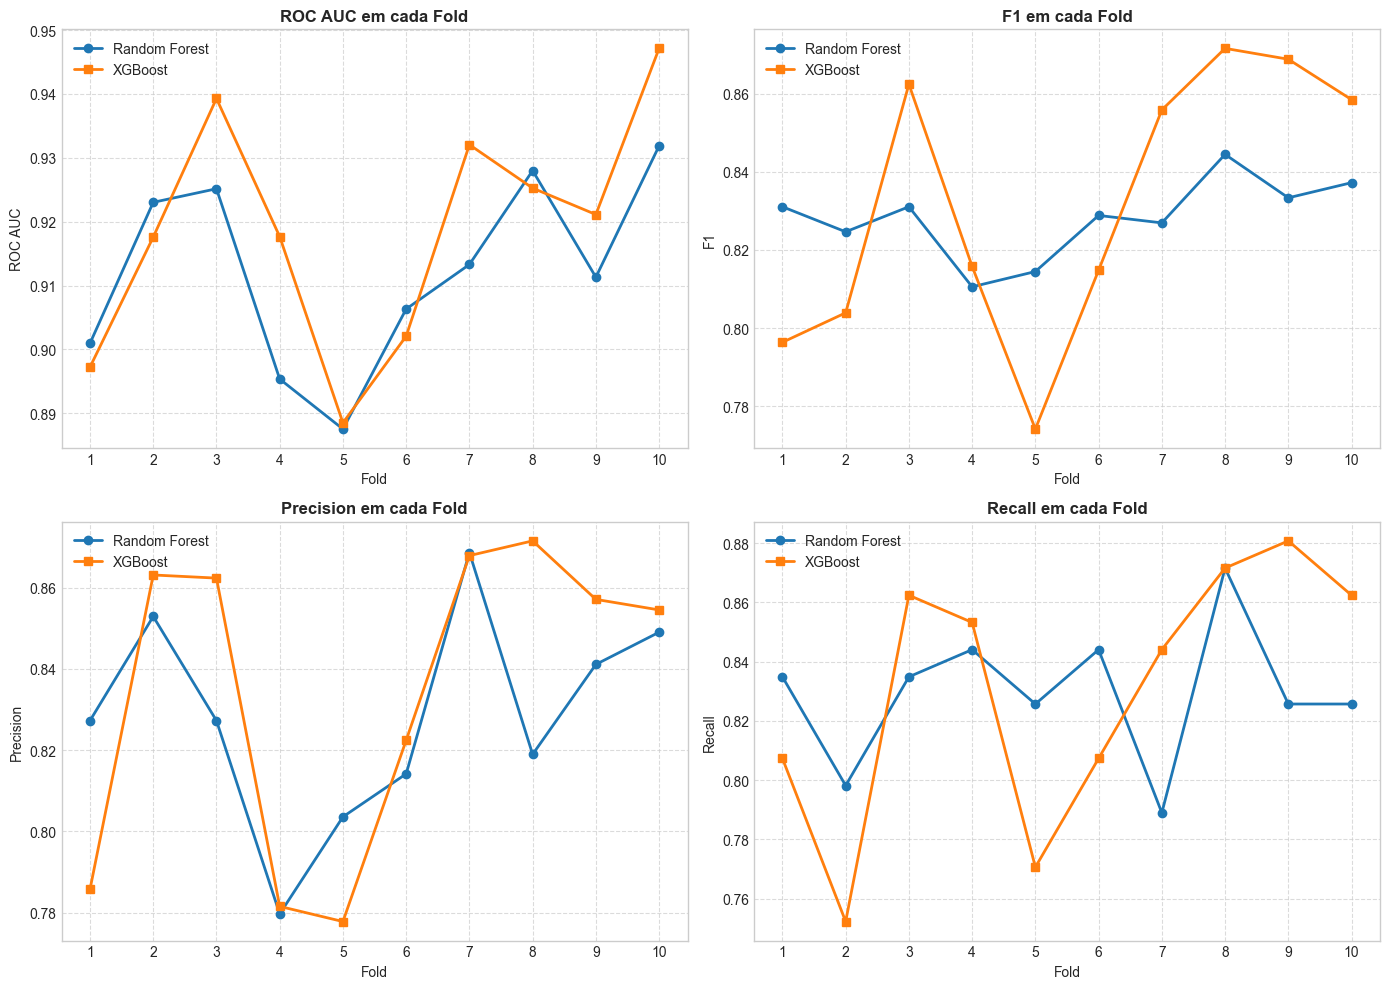

In [ ]:
# Performance em cada Fold para todas as métricas
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
axes2 = axes2.flatten()

colors_rf_xgb = ['#1f77b4', '#ff7f0e']

for idx, (metric, label) in enumerate(stats_metricas.items()):
    axes2[idx].plot(df_compare['fold'], df_compare[f'{metric}_rf'], 
                    marker='o', label='Random Forest', color=colors_rf_xgb[0], linewidth=2)
    axes2[idx].plot(df_compare['fold'], df_compare[f'{metric}_xgb'], 
                    marker='s', label='XGBoost', color=colors_rf_xgb[1], linewidth=2)
    axes2[idx].set_title(f'{label} em cada Fold', fontsize=12, fontweight='bold')
    axes2[idx].set_xlabel('Fold', fontsize=10)
    axes2[idx].set_ylabel(label, fontsize=10)
    axes2[idx].set_xticks(df_compare['fold'])
    axes2[idx].legend()
    axes2[idx].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

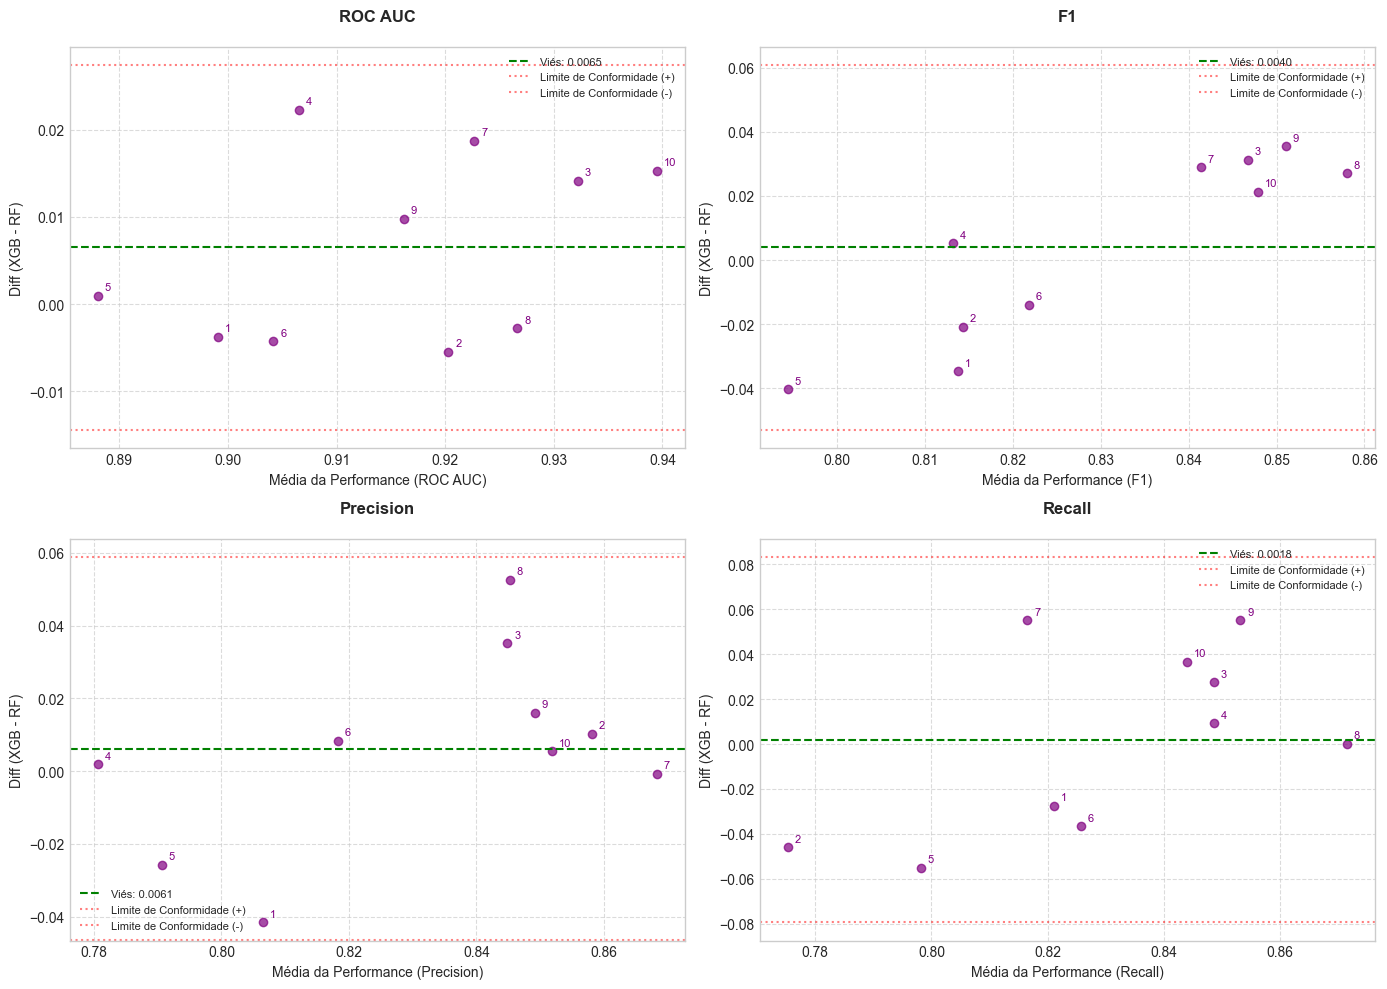

In [ ]:
# Bland-Altman Plot
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
axes3 = axes3.flatten()

for idx, (metric, label) in enumerate(stats_metricas.items()):
    mean_of_both = (df_compare[f'{metric}_rf'] + df_compare[f'{metric}_xgb']) / 2
    diff = df_compare[f'{metric}_xgb'] - df_compare[f'{metric}_rf']
    mean_diff = diff.mean()
    std_diff = diff.std()
    
    axes3[idx].scatter(mean_of_both, diff, color='purple', alpha=0.7)
    for x, y, fold in zip(mean_of_both, diff, df_compare['fold']):
        axes3[idx].annotate(str(int(fold)), (x, y), textcoords='offset points',
                            xytext=(5, 4), fontsize=8, color='purple')
    axes3[idx].axhline(mean_diff, color='green', linestyle='--',
                       label=f'Viés: {mean_diff:.4f}')
    axes3[idx].axhline(mean_diff + 1.96*std_diff, color='red', linestyle=':', 
                       alpha=0.5, label='Limite de Conformidade (+)')
    axes3[idx].axhline(mean_diff - 1.96*std_diff, color='red', linestyle=':', 
                       alpha=0.5, label='Limite de Conformidade (-)')
    axes3[idx].set_title(f'{label}\n', 
                         fontsize=12, fontweight='bold')
    axes3[idx].set_xlabel(f'Média da Performance ({label})', fontsize=10)
    axes3[idx].set_ylabel(f'Diff (XGB - RF)', fontsize=10)
    axes3[idx].legend(loc='best', fontsize=8)
    axes3[idx].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

 Concordância de Importância de Features

In [ ]:
BASE_DIR = Path(__file__).resolve().parent.parent
RF_RESULTS = os.path.join(BASE_DIR, "folds", "grid_search_rf")
XGB_RESULTS = os.path.join(BASE_DIR, "folds", "grid_search_xgb")

RF_FI_PATH = os.path.join(RF_RESULTS , "rf_feature_importance.csv")
XGB_FI_PATH = os.path.join(XGB_RESULTS, "xgb_feature_importance.csv") 

df_fi_rf = pd.read_csv(RF_FI_PATH)
df_fi_xgb = pd.read_csv(XGB_FI_PATH)

df_fi_rf.columns = [c.lower().strip() for c in df_fi_rf.columns]
df_fi_xgb.columns = [c.lower().strip() for c in df_fi_xgb.columns]

df_compare_fi = pd.merge(df_fi_rf, df_fi_xgb, on='feature', suffixes=('_rf', '_xgb'))

print(f"Features analisadas: {len(df_compare_fi)}")
display(df_compare_fi.sort_values(by='importance_mean_rf', ascending=False).head(50))

# T-TEST

# H0: A importância média dada pelo RF é igual à do XGB
t_stat_fi, p_val_fi = stats.ttest_rel(df_compare_fi['importance_mean_rf'], df_compare_fi['importance_mean_xgb'])

print(f"T-statistic: {t_stat_fi:.4f}")
print(f"P-value:     {p_val_fi:.4e}")

if p_val_fi < 0.05:
    print("Importâncias divergentes.")
else:
    print("Importâncias equivalentes.")

# SPEARMAN CORRELATION

# H0: Não há correlação entre os rankings
corr, p_spearman = stats.spearmanr(df_compare_fi['importance_mean_rf'], df_compare_fi['importance_mean_xgb'])

print(f"Coeficiente de Spearman: {corr:.4f} (-1 a +1)")
print(f"P-value:                {p_spearman:.4e}")

if p_spearman < 0.05:
    if corr > 0.7:
        print("Alta comcordancia.")
    elif 0.4 < corr <= 0.7:
        print("Moderada comcordancia.")
    else:
        print("Rankings divergentes.")
else:
    print("Correlação não significativa.")

Features analisadas: 48


,feature,importance_mean_rf,importance_std_rf,importance_mean_xgb,importance_std_xgb,importance_normalized
0,mean_raw_eda,0.057743,0.003081,2.991981,0.196217,0.044238
1,acc_y_mean,0.044984,0.001601,1.934310,0.099472,0.028600
2,mean_tonic_eda,0.041095,0.002159,1.910244,0.429681,0.028244
3,acc_x_mean,0.037749,0.001804,1.821917,0.146334,0.026938
4,acc_std,0.036330,0.003451,2.053812,0.179678,0.030367
5,acc_mean,0.035650,0.002082,1.576258,0.114054,0.023306
6,bvp_std,0.034313,0.001050,1.582025,0.108777,0.023391
7,hr_mean,0.031769,0.003060,1.809198,0.112697,0.026750
8,acc_z_mean,0.031016,0.001015,1.545721,0.112407,0.022854
9,scr_mean_amp,0.026122,0.001649,2.057103,0.230311,0.030416


T-statistic: -23.0562
P-value:     2.8827e-27
Importâncias divergentes.
Coeficiente de Spearman: 0.7765 (-1 a +1)
P-value:                8.8344e-11
Alta comcordancia.


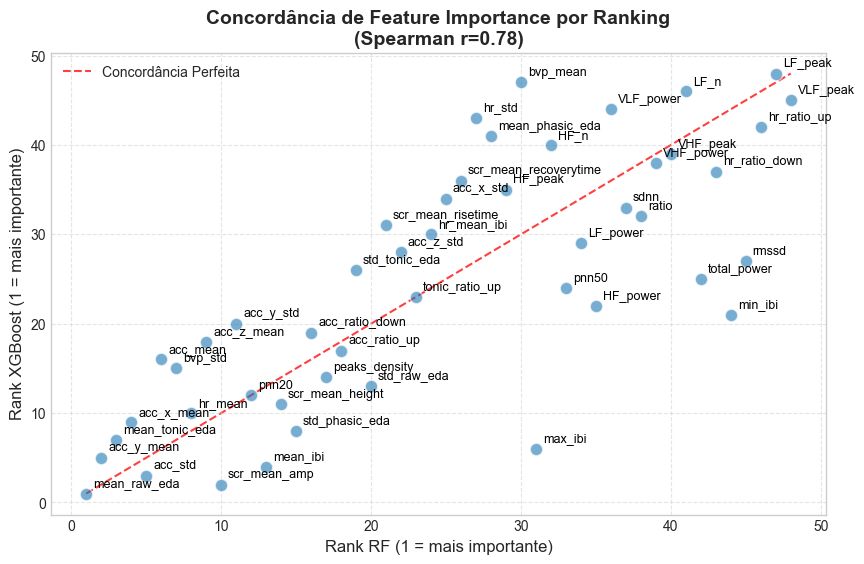

In [ ]:
df_compare_fi['rank_rf'] = df_compare_fi['importance_mean_rf'].rank(ascending=False)
df_compare_fi['rank_xgb'] = df_compare_fi['importance_mean_xgb'].rank(ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(df_compare_fi['rank_rf'], df_compare_fi['rank_xgb'], alpha=0.6, edgecolors='w', s=80)

lims = [1, len(df_compare_fi)]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Concordância Perfeita')

top_features = df_compare_fi.nsmallest(48, 'rank_rf')['feature']
for feature in top_features:
    row = df_compare_fi[df_compare_fi['feature'] == feature].iloc[0]
    plt.annotate(row['feature'],
                 (row['rank_rf'], row['rank_xgb']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, color='black')

plt.xlabel('Rank RF (1 = mais importante)', fontsize=12)
plt.ylabel('Rank XGBoost (1 = mais importante)', fontsize=12)
plt.title('Concordância de Feature Importance por Ranking\n(Spearman r={:.2f})'.format(corr), fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca()
plt.gca()
plt.show()

No kernel connected